In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx
from probjax.nn.nets.lru import LRU


In [3]:
class Model(nnx.Module, experimental_pytree=True):
    def __init__(self, rnn, hidden_dim, output_dim, rngs):
        self.rnn = rnn
        self.dense = nnx.Linear(hidden_dim, output_dim, rngs=rngs)

    def __call__(self, x):
        x = jnp.ones_like(x)
        h = self.rnn(x)
        return self.dense(h)
    


In [18]:
rnn = nnx.RNN(nnx.LSTMCell(1,10, rngs=nnx.Rngs(0)))
lrnn = LRU(1, 10, 10, rngs=nnx.Rngs(0))

# Nonlinear RNN
model = Model(rnn, 10, 1, rngs=nnx.Rngs(1))
# Linear RNN
#model = Model(lrnn, 10, 1, rngs=nnx.Rngs(1))

In [19]:
nnx.display(model)

In [21]:
params = nnx.state(model, nnx.Param)

In [22]:
# Seqlength of task - difference becomes more apparent with longer sequences
seqlen = 100
x = jnp.linspace(0, 10, seqlen).reshape(-1,1)
y = jnp.sin(x)

In [23]:
def loss_fn(params,model, x, y):
    nnx.update(model, params)
    y_pred = model(x)
    return jnp.sum((y - y_pred)**2)

import optax

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)

@jax.jit
def update(params, opt_state, x, y, model):
    loss, grads = jax.value_and_grad(loss_fn)(params,model, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


In [24]:
for i in range(10_000):
    params, opt_state, loss = update(params, opt_state, x, y, model)
    if i % 1000 == 0:
        print(loss)

128.49591
31.809956
0.008246524
0.010506909


KeyboardInterrupt: 

In [15]:
nnx.update(model, params)

In [16]:
y_pred = model(x)

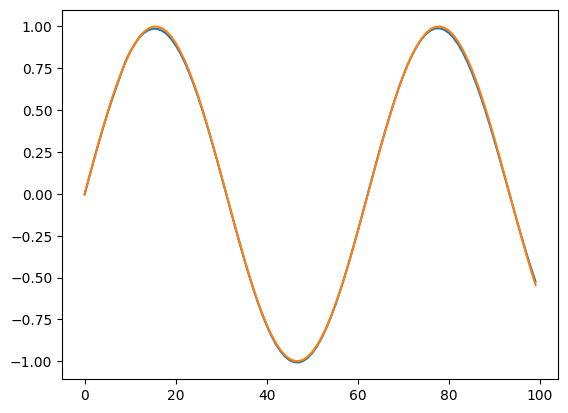

In [17]:
plt.plot(y_pred.flatten())
plt.plot(y.flatten())